# Imports

In [22]:
from torch.utils.data import DataLoader, random_split
import torch
from data import PermutationDataset
from model import PermutationModel
from train import train_one_epoch, evaluate_model
import matplotlib.pyplot as plt

# Parameters
This includes parameters for what to train on and predict, and also the hyperparameters for training.

In [23]:
n = 9
label_name = "stat2"
layers = [2]

epochs = 100
train_split, test_split = 0.8, 0.2
learning_rate = 0.001
momentum = 0.9
batch_size = 64

# Initialization
Initialize the data loaders, model, loss function, optimizers.

In [24]:
full_dataset = PermutationDataset(n, label_name)
training_dataset, test_dataset = random_split(full_dataset, [train_split, test_split])
model = PermutationModel(n, layers)
loss_fn = torch.nn.CrossEntropyLoss(full_dataset.class_weights())
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
losses = []

# Training loop
Train the model for the appropriate number of epochs and then save the model in `models`.

In [25]:
for epoch in range(epochs):
    model.train(True)
    current_loss = train_one_epoch(training_loader, model, loss_fn, optimizer)
    print(f"Epoch {epoch}, Loss {current_loss}")
    losses.append(current_loss)

torch.save(model.state_dict(), f"models/{label_name}_{n}.pt")

Epoch 0, Loss 1554.809868350625
Epoch 1, Loss 792.117847494781
Epoch 2, Loss 594.7331636026502
Epoch 3, Loss 491.1763439849019
Epoch 4, Loss 424.6160390675068
Epoch 5, Loss 377.20440520718694
Epoch 6, Loss 341.24070581421256
Epoch 7, Loss 312.75000650808215
Epoch 8, Loss 289.47921119071543
Epoch 9, Loss 270.01082551665604
Epoch 10, Loss 253.41864111088216
Epoch 11, Loss 239.07966080494225
Epoch 12, Loss 226.51611937955022
Epoch 13, Loss 215.40486415475607
Epoch 14, Loss 205.48061002232134
Epoch 15, Loss 196.5566804409027
Epoch 16, Loss 188.48563681915402
Epoch 17, Loss 181.12461790442467
Epoch 18, Loss 174.39792779181153
Epoch 19, Loss 168.20991396345198
Epoch 20, Loss 162.4943082779646
Epoch 21, Loss 157.2024907981977
Epoch 22, Loss 152.2796694971621
Epoch 23, Loss 147.6886323299259
Epoch 24, Loss 143.3963614553213
Epoch 25, Loss 139.36853102594614
Epoch 26, Loss 135.58637784421444
Epoch 27, Loss 132.02282109297812
Epoch 28, Loss 128.65852908976376
Epoch 29, Loss 125.47766266949475
Ep

# Print the loss curve
Visualize the loss curve to ensure that the model is learning correctly. Save the loss curve in `figures/` so that you can refer to them later.

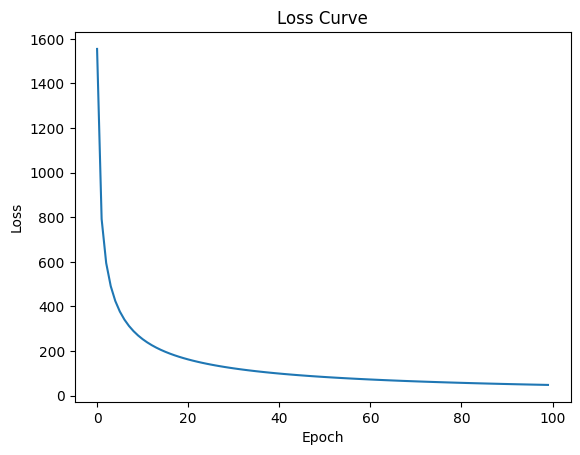

In [26]:
# TODO
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the loss curve
ax.plot(range(len(losses)), losses)

# Add labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')

fig.savefig(f'figures/loss_curve_stat2_{n}.png', dpi=300)
# Show the plot
plt.show()

# Evaluate the model
Compute the confusion matrix on the train and test dataset and print out the accuracy and plot the confusion matrix.

In [27]:
# TODO
confusion_matrix = evaluate_model(model, test_dataset)
confusion_matrix.print_accuracy()

Accuracy for class 0 = 100.0%
Accuracy for class 1 = 100.0%
Overall accuracy = 100.0%


# Plot model weights and connections.
Plot the model weights and connections in order to attempt to interpret what the model is learning.

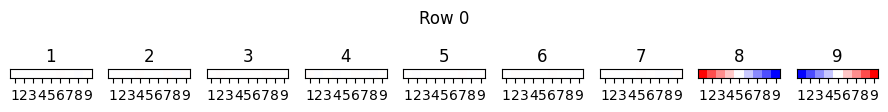

In [28]:
model.plot_heatmap_feature(0,0)